<a href="https://colab.research.google.com/github/sabrinaa-tang/tanzania-project/blob/main/Tanzania_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import cross_val_score
original_df = pd.read_csv('Tanzania.csv')
original_df.head()

,Country Name,Country Code,Series Name,Series Code,1999 [YR1999],2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],...,2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Tanzania,TZA,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,..,0.7,0.7,0.7,0.7,0.8,...,2.7,3.2,3.9,4.5,5.3,6.2,7.2,8.1,9.2,..
1,Tanzania,TZA,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,..,0.2,0.2,0.2,0.2,0.3,...,0.7,0.9,1,1.1,1.3,1.6,1.8,2.1,2.4,..
2,Tanzania,TZA,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,..,1.7,1.8,1.9,1.9,1.9,...,7,8.4,9.8,11.6,13.3,15.4,17.6,19.9,22.3,..
3,Tanzania,TZA,Access to electricity (% of population),EG.ELC.ACCS.ZS,8,8.7,9.7,10.7,11.1,11.4,...,23.5,26.2,32.8,32.1,34.9,37.7,39.9,42.7,45.8,..
4,Tanzania,TZA,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,2.57321178552214,1.7,2.5,3.2,3.2,2.6,...,10,11.3,17.3,16,18.1,19,22,23.3,36,..


In [ ]:
##drop country name, country code and series code

In [ ]:
original_df.drop(['Country Name', 'Country Code', 'Series Code'], axis=1, inplace=True)

In [ ]:
original_df.head()

,Series Name,1999 [YR1999],2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],2006 [YR2006],2007 [YR2007],...,2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Access to clean fuels and technologies for coo...,..,0.7,0.7,0.7,0.7,0.8,0.8,0.9,1,...,2.7,3.2,3.9,4.5,5.3,6.2,7.2,8.1,9.2,..
1,Access to clean fuels and technologies for coo...,..,0.2,0.2,0.2,0.2,0.3,0.3,0.3,0.3,...,0.7,0.9,1,1.1,1.3,1.6,1.8,2.1,2.4,..
2,Access to clean fuels and technologies for coo...,..,1.7,1.8,1.9,1.9,1.9,2,2.2,2.4,...,7,8.4,9.8,11.6,13.3,15.4,17.6,19.9,22.3,..
3,Access to electricity (% of population),8,8.7,9.7,10.7,11.1,11.4,13.8,14.9,15.9,...,23.5,26.2,32.8,32.1,34.9,37.7,39.9,42.7,45.8,..
4,"Access to electricity, rural (% of rural popul...",2.57321178552214,1.7,2.5,3.2,3.2,2.6,4.9,5.5,6,...,10,11.3,17.3,16,18.1,19,22,23.3,36,..


In [ ]:
#Changed the column names from 'year' [YR'year'] to 'year' for simplicity
reg_pattern = '\s*\[.*\]'
for i in range(len(original_df.columns)):
    original_df.rename(columns = {original_df.columns[i]: re.sub(reg_pattern, '', original_df.columns[i])}, inplace=True)

In [ ]:
original_df.head()

,Series Name,1999,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Access to clean fuels and technologies for coo...,..,0.7,0.7,0.7,0.7,0.8,0.8,0.9,1,...,2.7,3.2,3.9,4.5,5.3,6.2,7.2,8.1,9.2,..
1,Access to clean fuels and technologies for coo...,..,0.2,0.2,0.2,0.2,0.3,0.3,0.3,0.3,...,0.7,0.9,1,1.1,1.3,1.6,1.8,2.1,2.4,..
2,Access to clean fuels and technologies for coo...,..,1.7,1.8,1.9,1.9,1.9,2,2.2,2.4,...,7,8.4,9.8,11.6,13.3,15.4,17.6,19.9,22.3,..
3,Access to electricity (% of population),8,8.7,9.7,10.7,11.1,11.4,13.8,14.9,15.9,...,23.5,26.2,32.8,32.1,34.9,37.7,39.9,42.7,45.8,..
4,"Access to electricity, rural (% of rural popul...",2.57321178552214,1.7,2.5,3.2,3.2,2.6,4.9,5.5,6,...,10,11.3,17.3,16,18.1,19,22,23.3,36,..


In [ ]:
#transposed the dataframe and made the columns the indexes
t_df = original_df.set_index("Series Name")
transposed_df = t_df.T
transposed_df.head()

Series Name,Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),"Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, older adults (% of population ages 25+)",...,Women who believe a husband is justified in beating his wife when she refuses sex with him (%),Women who were first married by age 15 (% of women ages 20-24),Women who were first married by age 18 (% of women ages 20-24),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV,NaN,NaN,NaN,NaN,NaN
1999,..,..,..,8,2.57321178552214,27.3,..,..,..,..,...,..,6.4,39.3,59.9878877884292,39000,NaN,NaN,NaN,NaN,NaN
2000,0.7,0.2,1.7,8.7,1.7,32.7,..,..,..,..,...,..,..,..,60.2027189932565,38000,NaN,NaN,NaN,NaN,NaN
2001,0.7,0.2,1.8,9.7,2.5,34.3,..,..,..,..,...,..,..,..,60.305353482331,36000,NaN,NaN,NaN,NaN,NaN
2002,0.7,0.2,1.9,10.7,3.2,35.9,..,..,..,..,...,..,..,..,60.393261891469,35000,NaN,NaN,NaN,NaN,NaN
2003,0.7,0.2,1.9,11.1,3.2,36.5,..,..,..,..,...,..,..,..,60.4296031877802,34000,NaN,NaN,NaN,NaN,NaN


In [ ]:
#drop all NaN columns

transposed_df.dropna(axis=1, inplace=True)
transposed_df

Series Name,Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),"Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, older adults (% of population ages 25+)",...,Women who believe a husband is justified in beating his wife (any of five reasons) (%),Women who believe a husband is justified in beating his wife when she argues with him (%),Women who believe a husband is justified in beating his wife when she burns the food (%),Women who believe a husband is justified in beating his wife when she goes out without telling him (%),Women who believe a husband is justified in beating his wife when she neglects the children (%),Women who believe a husband is justified in beating his wife when she refuses sex with him (%),Women who were first married by age 15 (% of women ages 20-24),Women who were first married by age 18 (% of women ages 20-24),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
1999,..,..,..,8,2.57321178552214,27.3,..,..,..,..,...,..,..,..,..,..,..,6.4,39.3,59.9878877884292,39000
2000,0.7,0.2,1.7,8.7,1.7,32.7,..,..,..,..,...,..,..,..,..,..,..,..,..,60.2027189932565,38000
2001,0.7,0.2,1.8,9.7,2.5,34.3,..,..,..,..,...,..,..,..,..,..,..,..,..,60.305353482331,36000
2002,0.7,0.2,1.9,10.7,3.2,35.9,..,..,..,..,...,..,..,..,..,..,..,..,..,60.393261891469,35000
2003,0.7,0.2,1.9,11.1,3.2,36.5,..,..,..,..,...,..,..,..,..,..,..,..,..,60.4296031877802,34000
2004,0.8,0.3,1.9,11.4,2.6,38.9,..,..,..,..,...,..,..,..,..,..,..,7,35.3,60.4604960984371,33000
2005,0.8,0.3,2,13.8,4.9,40.6,..,..,..,..,...,59.6,45.9,19.6,42.8,47.2,29,6.4,41.1,60.4833711692224,32000
2006,0.9,0.3,2.2,14.9,5.5,42.3,..,..,..,..,...,..,..,..,..,..,..,..,..,60.4927056330784,31000
2007,1,0.3,2.4,15.9,6,44,..,..,..,..,...,..,..,..,..,..,..,..,..,60.4743183538922,30000
2008,1.1,0.4,2.7,11.5,1,40.1,..,..,..,..,...,..,..,..,..,..,..,5.9,37.8,60.3909308864583,29000


In [ ]:
#Wanted to remove all columns that had more than 12 ".." values because thats more than half

for col in transposed_df.columns:
    if sum(transposed_df[col] == "..") > 4:
        transposed_df.drop(col, axis=1, inplace = True)

In [ ]:
transposed_df.shape
transposed_df.head()

Series Name,Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),...,"Vulnerable employment, female (% of female employment) (modeled ILO estimate)","Vulnerable employment, male (% of male employment) (modeled ILO estimate)","Vulnerable employment, total (% of total employment) (modeled ILO estimate)","Wage and salaried workers, female (% of female employment) (modeled ILO estimate)","Wage and salaried workers, male (% of male employment) (modeled ILO estimate)","Wage and salaried workers, total (% of total employment) (modeled ILO estimate)","Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)",Women Business and the Law Index Score (scale 1-100),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
1999,..,..,..,8,2.57321178552214,27.3,7.19646439422834,14228608339.7197,10511073723.1118,4.37107471027609,...,93.9492943637643,83.837733700338,88.8436211200576,5.28690162901195,14.3828780318793,9.87977160144715,4.65816179848478,67.5,59.9878877884292,39000
2000,0.7,0.2,1.7,8.7,1.7,32.7,5.37144738799122,14992890550.7311,11172782443.5837,2.4263100403541,...,93.8490837593523,83.6977872653398,88.7265855659233,5.36170406078687,14.5060911742752,9.97610050723953,4.34025002935435,67.5,60.2027189932565,38000
2001,0.7,0.2,1.8,9.7,2.5,34.3,6.33265727050501,15942338924.2509,11286858012.7584,3.50547322023063,...,93.7205152958445,83.4444163381891,88.5418936222288,5.48117510306409,14.7164568373772,10.1352788002294,4.15294104395533,67.5,60.305353482331,36000
2002,0.7,0.2,1.9,10.7,3.2,35.9,11.7260655202276,17811748031.9653,12081767704.326,8.87847882550123,...,93.5803521483179,83.1192258883323,88.3138254925915,5.62864422192872,14.9800631771601,10.3365081767799,4.0508579512518,67.5,60.393261891469,35000
2003,0.7,0.2,1.9,11.1,3.2,36.5,4.8934163299313,18683351018.8077,13001580705.8234,2.16042281875789,...,93.3897855410827,82.762964501335,88.0448274057122,5.82164840601101,15.2772279200081,10.5775036186938,4.32116318867234,67.5,60.4296031877802,34000


In [ ]:

#make every value in the table floats while excluding ".."
for col in transposed_df.columns:
    transposed_df[col] = pd.to_numeric(transposed_df[col], errors='coerce')

five_missing_df = transposed_df
#filled mean values for all columns
for col in five_missing_df.columns:
    mean = five_missing_df[col].mean()
    five_missing_df[col].fillna(mean, inplace=True)

five_missing_df.head(25)

<ipython-input-12-389f8120b48b>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  five_missing_df[col].fillna(mean, inplace=True)


Series Name,Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),...,"Vulnerable employment, female (% of female employment) (modeled ILO estimate)","Vulnerable employment, male (% of male employment) (modeled ILO estimate)","Vulnerable employment, total (% of total employment) (modeled ILO estimate)","Wage and salaried workers, female (% of female employment) (modeled ILO estimate)","Wage and salaried workers, male (% of male employment) (modeled ILO estimate)","Wage and salaried workers, total (% of total employment) (modeled ILO estimate)","Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)",Women Business and the Law Index Score (scale 1-100),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
1999,2.869565,0.773913,7.191304,8.000000,2.573212,27.300000,7.196464,1.422861e+10,1.051107e+10,4.371075,...,93.949294,83.837734,88.843621,5.286902,14.382878,9.879772,4.658162,67.50,59.987888,39000.000000
2000,0.700000,0.200000,1.700000,8.700000,1.700000,32.700000,5.371447,1.499289e+10,1.117278e+10,2.426310,...,93.849084,83.697787,88.726586,5.361704,14.506091,9.976101,4.340250,67.50,60.202719,38000.000000
2001,0.700000,0.200000,1.800000,9.700000,2.500000,34.300000,6.332657,1.594234e+10,1.128686e+10,3.505473,...,93.720515,83.444416,88.541894,5.481175,14.716457,10.135279,4.152941,67.50,60.305353,36000.000000
2002,0.700000,0.200000,1.900000,10.700000,3.200000,35.900000,11.726066,1.781175e+10,1.208177e+10,8.878479,...,93.580352,83.119226,88.313825,5.628644,14.980063,10.336508,4.050858,67.50,60.393262,35000.000000
2003,0.700000,0.200000,1.900000,11.100000,3.200000,36.500000,4.893416,1.868335e+10,1.300158e+10,2.160423,...,93.389786,82.762965,88.044827,5.821648,15.277228,10.577504,4.321163,67.50,60.429603,34000.000000
2004,0.800000,0.300000,1.900000,11.400000,2.600000,38.900000,7.158673,2.002083e+10,1.434414e+10,4.295717,...,93.208782,82.377065,87.765589,6.017307,15.592058,10.828846,4.645415,67.50,60.460496,33000.000000
2005,0.800000,0.300000,2.000000,13.800000,4.900000,40.600000,10.293581,2.208169e+10,1.593769e+10,7.280481,...,93.038867,82.015276,87.503083,6.203315,15.883797,11.064617,4.992721,81.25,60.483371,32000.000000
2006,0.900000,0.300000,2.200000,14.900000,5.500000,42.300000,9.758600,2.423656e+10,1.645575e+10,6.732989,...,92.823128,81.643560,87.211958,6.421478,16.190525,11.324690,5.318857,81.25,60.492706,31000.000000
2007,1.000000,0.300000,2.400000,15.900000,6.000000,44.000000,3.564806,2.510054e+10,1.896305e+10,0.719236,...,92.653275,81.317847,86.969292,6.595807,16.456175,11.540143,5.678866,81.25,60.474318,30000.000000
2008,1.100000,0.400000,2.700000,11.500000,1.000000,40.100000,2.553240,2.574142e+10,2.415128e+10,-0.176251,...,92.333681,80.853875,86.583486,6.901660,16.842405,11.880944,6.001790,81.25,60.390931,29000.000000


In [ ]:
cleaned_df = five_missing_df

In [ ]:
#how to see all the columns that contain HIV in the name
for col in cleaned_df.columns:
    if "HIV" in col:
        print(col)

Adults (ages 15+) and children (ages 0-14) newly infected with HIV
Adults (ages 15-49) newly infected with HIV
Antiretroviral therapy coverage (% of people living with HIV)
Antiretroviral therapy coverage for PMTCT (% of pregnant women living with HIV)
Children (0-14) living with HIV
Children (ages 0-14) newly infected with HIV
Incidence of HIV, ages 15-24 (per 1,000 uninfected population ages 15-24)
Incidence of HIV, ages 15-49 (per 1,000 uninfected population ages 15-49)
Incidence of HIV, all (per 1,000 uninfected population)
Prevalence of HIV, female (% ages 15-24)
Prevalence of HIV, male (% ages 15-24)
Prevalence of HIV, total (% of population ages 15-49)
Women's share of population ages 15+ living with HIV (%)
Young people (ages 15-24) newly infected with HIV


Series Name,Adults (ages 15-49) newly infected with HIV,Children (ages 0-14) newly infected with HIV
Series Name,,
Adults (ages 15-49) newly infected with HIV,1.000000,0.743956
Children (ages 0-14) newly infected with HIV,0.743956,1.000000


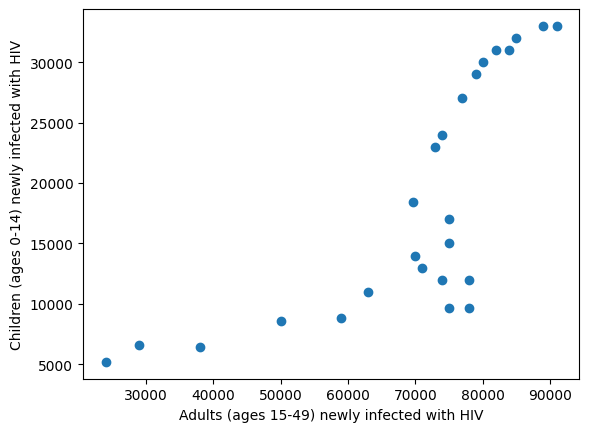

In [ ]:
#create scatter plot to see if adults newly infected with HIV and positively correlated with childrren newly infected with HIV
plt.scatter(cleaned_df["Adults (ages 15-49) newly infected with HIV"], cleaned_df["Children (ages 0-14) newly infected with HIV"])
plt.xlabel("Adults (ages 15-49) newly infected with HIV")
plt.ylabel("Children (ages 0-14) newly infected with HIV")
#checking to see how corrleated newly infected children and adults are
newly_column_df = cleaned_df[["Adults (ages 15-49) newly infected with HIV", "Children (ages 0-14) newly infected with HIV"]]
newly_column_df.corr()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24],
 [Text(0, 0, '1999'),
  Text(1, 0, '2000'),
  Text(2, 0, '2001'),
  Text(3, 0, '2002'),
  Text(4, 0, '2003'),
  Text(5, 0, '2004'),
  Text(6, 0, '2005'),
  Text(7, 0, '2006'),
  Text(8, 0, '2007'),
  Text(9, 0, '2008'),
  Text(10, 0, '2009'),
  Text(11, 0, '2010'),
  Text(12, 0, '2011'),
  Text(13, 0, '2012'),
  Text(14, 0, '2013'),
  Text(15, 0, '2014'),
  Text(16, 0, '2015'),
  Text(17, 0, '2016'),
  Text(18, 0, '2017'),
  Text(19, 0, '2018'),
  Text(20, 0, '2019'),
  Text(21, 0, '2020'),
  Text(22, 0, '2021'),
  Text(23, 0, '2022'),
  Text(24, 0, '2023')])

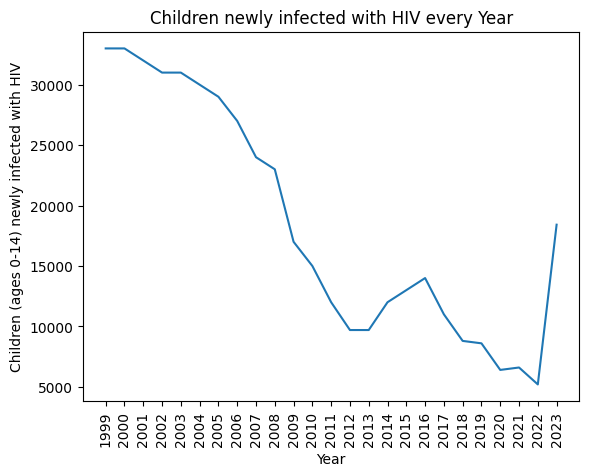

In [ ]:
#plot trend of "Children (ages 0-14) newly infected with HIV"
plt.plot(cleaned_df.index, cleaned_df["Children (ages 0-14) newly infected with HIV"])
plt.xlabel("Year")
plt.ylabel("Children (ages 0-14) newly infected with HIV")
plt.title('Children newly infected with HIV every Year')
plt.xticks(rotation='vertical') #change x labels to vertical

In [ ]:
#Predict how many children in the next few years will be infected with HIV and what factors influence HIV the most
#columns to use: Children (ages 0-14) newly infected with HIV, Population ages 0-14, total, Adjusted net national income per capita (current US$), Adjusted savings: education expenditure (current US$)


In [ ]:
#create a column in cleaned df that creates a percentage of these two columns Children (ages 0-14) newly infected with HIV, Population ages 0-14, total
cleaned_df["Percentage of Children Infected"] = cleaned_df["Children (ages 0-14) newly infected with HIV"] / cleaned_df["Population ages 0-14, total"]
#compare percentage of children infected by every other column through correlations and remove all other rows to compare it to other than the interested one
correlated = cleaned_df.loc[:, abs(cleaned_df.corr()["Children (ages 0-14) newly infected with HIV"]) < 0.5]
for col in correlated.columns:
    print(col)
#show me the correlation between the first five columns in cleaned_df compared to "Percentage of Children Infected"

<ipython-input-17-bf09aff43b5a>:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cleaned_df["Percentage of Children Infected"] = cleaned_df["Children (ages 0-14) newly infected with HIV"] / cleaned_df["Population ages 0-14, total"]


Adjusted net national income (annual % growth)
Adjusted net national income per capita (annual % growth)
Adjusted net savings, excluding particulate emission damage (% of GNI)
Adjusted net savings, including particulate emission damage (% of GNI)
Adjusted savings: consumption of fixed capital (% of GNI)
Adjusted savings: net national savings (% of GNI)
Age dependency ratio (% of working-age population)
Age dependency ratio, young (% of working-age population)
Agriculture, forestry, and fishing, value added (% of GDP)
Agriculture, forestry, and fishing, value added (annual % growth)
Air transport, freight (million ton-km)
Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)
Annual freshwater withdrawals, domestic (% of total freshwater withdrawal)
Annual freshwater withdrawals, industry (% of total freshwater withdrawal)
Annual freshwater withdrawals, total (% of internal resources)
Annual freshwater withdrawals, total (billion cubic meters)
Arable land (hectare

In [ ]:
#check for colinearlity between x variables below (get rid of one)
#if correlated remove one and pick a different feature
#Mobile cellular subscriptions (per 100 people), Access to electricity (% of population), Number of neonatal deaths, Refugee population by country or territory of origin, Domestic general government health expenditure per capita, PPP (current international $)
#change percentages to numbers to use in linear regression

In [ ]:
#create a corelation matrix of all the columns in correlated abbove
correlated.corr()

Series Name,Adjusted net national income (annual % growth),Adjusted net national income per capita (annual % growth),"Adjusted net savings, excluding particulate emission damage (% of GNI)","Adjusted net savings, including particulate emission damage (% of GNI)",Adjusted savings: consumption of fixed capital (% of GNI),Adjusted savings: net national savings (% of GNI),Age dependency ratio (% of working-age population),"Age dependency ratio, young (% of working-age population)","Agriculture, forestry, and fishing, value added (% of GDP)","Agriculture, forestry, and fishing, value added (annual % growth)",...,Trade in services (% of GDP),"Unemployment, female (% of female labor force) (modeled ILO estimate)","Unemployment, youth female (% of female labor force ages 15-24) (modeled ILO estimate)","Use of IMF credit (DOD, current US$)",Vitamin A supplementation coverage rate (% of children ages 6-59 months),Voice and Accountability: Estimate,Voice and Accountability: Number of Sources,Voice and Accountability: Percentile Rank,"Voice and Accountability: Percentile Rank, Lower Bound of 90% Confidence Interval","Voice and Accountability: Percentile Rank, Upper Bound of 90% Confidence Interval"
Series Name,,,,,,,,,,,,,,,,,,,,,
Adjusted net national income (annual % growth),1.000000,0.998338,-0.002846,-0.001752,-0.107528,-0.006928,-0.022322,-0.024369,0.144154,0.276711,...,0.171147,-0.251082,-0.174519,0.022027,0.137055,0.073238,-0.153521,0.006185,0.020928,0.053223
Adjusted net national income per capita (annual % growth),0.998338,1.000000,-0.022923,-0.024075,-0.103778,-0.028362,-0.001388,-0.001239,0.113491,0.270660,...,0.187323,-0.239001,-0.151428,0.016166,0.144183,0.077553,-0.157628,0.017487,0.024662,0.066810
"Adjusted net savings, excluding particulate emission damage (% of GNI)",-0.002846,-0.022923,1.000000,0.997094,-0.725112,0.997938,-0.371204,-0.372887,0.030441,0.139383,...,-0.206505,-0.060276,-0.409358,-0.198090,-0.033557,-0.237436,0.029869,-0.334825,-0.186928,-0.449195
"Adjusted net savings, including particulate emission damage (% of GNI)",-0.001752,-0.024075,0.997094,1.000000,-0.682090,0.997671,-0.353342,-0.359025,0.051368,0.134739,...,-0.191335,-0.057312,-0.398785,-0.176807,-0.010127,-0.202336,0.079020,-0.300820,-0.145389,-0.423687
Adjusted savings: consumption of fixed capital (% of GNI),-0.107528,-0.103778,-0.725112,-0.682090,1.000000,-0.708931,0.518622,0.489599,0.212709,-0.127725,...,0.322055,0.025916,0.420808,0.173110,0.112351,0.509948,0.411182,0.570955,0.534896,0.599722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Voice and Accountability: Estimate,0.073238,0.077553,-0.237436,-0.202336,0.509948,-0.239683,0.842901,0.828331,0.156437,0.234100,...,0.813326,-0.041351,0.448743,-0.398761,0.438480,1.000000,0.693037,0.962947,0.965866,0.924661
Voice and Accountability: Number of Sources,-0.153521,-0.157628,0.029869,0.079020,0.411182,0.040880,0.517170,0.489116,0.057701,-0.038881,...,0.523971,0.251714,0.421011,-0.113680,0.520805,0.693037,1.000000,0.685467,0.816880,0.484434
Voice and Accountability: Percentile Rank,0.006185,0.017487,-0.334825,-0.300820,0.570955,-0.334200,0.869456,0.858246,0.011708,0.174479,...,0.785153,0.057247,0.554736,-0.341627,0.421582,0.962947,0.685467,1.000000,0.946637,0.939225


In [ ]:
#Create a features_df that has Mobile cellular subscriptions (per 100 people), Access to electricity (% of population), Refugee population by country or territory of origin, Domestic general government health expenditure per capita, PPP (current international $) all standardized into numbers instead of percentage
features_df = cleaned_df
features_df["Children (ages 0-14) newly infected with HIV"] = features_df["Children (ages 0-14) newly infected with HIV"] / features_df["Population ages 0-14, total"]
features_df["Access to electricity (% of population)"] = features_df["Access to electricity (% of population)"] * 0.01
features_df["Mobile cellular subscriptions (per 100 people)"] = features_df["Mobile cellular subscriptions (per 100 people)"] * 0.01
features_df["Domestic general government health expenditure per capita, PPP (current international $)"] = features_df["Domestic general government health expenditure per capita, PPP (current international $)"] * 0.01
features_df["Refugee population by country or territory of origin"] = features_df["Refugee population by country or territory of asylum"] / features_df["Population, total"]
features_df["Number of neonatal deaths"] = features_df["Number of neonatal deaths"] / features_df["Population, total"]
#standardize all columns
features_df.head()

Series Name,Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),...,"Vulnerable employment, male (% of male employment) (modeled ILO estimate)","Vulnerable employment, total (% of total employment) (modeled ILO estimate)","Wage and salaried workers, female (% of female employment) (modeled ILO estimate)","Wage and salaried workers, male (% of male employment) (modeled ILO estimate)","Wage and salaried workers, total (% of total employment) (modeled ILO estimate)","Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)",Women Business and the Law Index Score (scale 1-100),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV,Percentage of Children Infected
1999,2.869565,0.773913,7.191304,0.080,2.573212,27.3,7.196464,1.422861e+10,1.051107e+10,4.371075,...,83.837734,88.843621,5.286902,14.382878,9.879772,4.658162,67.5,59.987888,39000.0,0.002219
2000,0.700000,0.200000,1.700000,0.087,1.700000,32.7,5.371447,1.499289e+10,1.117278e+10,2.426310,...,83.697787,88.726586,5.361704,14.506091,9.976101,4.340250,67.5,60.202719,38000.0,0.002162
2001,0.700000,0.200000,1.800000,0.097,2.500000,34.3,6.332657,1.594234e+10,1.128686e+10,3.505473,...,83.444416,88.541894,5.481175,14.716457,10.135279,4.152941,67.5,60.305353,36000.0,0.002042
2002,0.700000,0.200000,1.900000,0.107,3.200000,35.9,11.726066,1.781175e+10,1.208177e+10,8.878479,...,83.119226,88.313825,5.628644,14.980063,10.336508,4.050858,67.5,60.393262,35000.0,0.001925
2003,0.700000,0.200000,1.900000,0.111,3.200000,36.5,4.893416,1.868335e+10,1.300158e+10,2.160423,...,82.762965,88.044827,5.821648,15.277228,10.577504,4.321163,67.5,60.429603,34000.0,0.001873


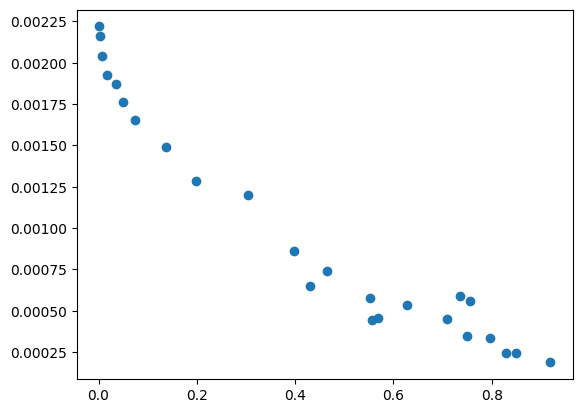

In [ ]:
#scikit learn linear regression
#split 80-20 training/test
#fit model
#see accuracy (intuition: check error in context; mse in scikit)
#Number of children newly infected with HIV in future years
#Possibly communicate in one slide outside research to support result
#Say at end of slide what country we're working on and what's next (conclusion)
plt.scatter(features_df["Mobile cellular subscriptions (per 100 people)"], features_df["Children (ages 0-14) newly infected with HIV"])

In [ ]:
#Linear regression on chosen features
Y = features_df["Children (ages 0-14) newly infected with HIV"]
X = features_df[["Mobile cellular subscriptions (per 100 people)", "Refugee population by country or territory of asylum", "Domestic general government health expenditure per capita, PPP (current international $)", "Number of neonatal deaths"]]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
model = LinearRegression()
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(Y_test, y_pred)
print(f"Mean Squared Error: {mse}")

r2 = r2_score(Y_test, y_pred)
print(f"R-squared: {r2}")


Mean Squared Error: 1.380680319032829e-09
R-squared: 0.9948444583529749


In [ ]:
scores = cross_val_score(model, X, Y, cv=5, scoring='neg_mean_squared_error')  # 5-fold cross-validation

# Convert negative MSE to positive
scores = -scores

# Print the cross-validation scores (Mean Squared Error)
print("Cross-validation MSE scores:", scores)

Cross-validation MSE scores: [1.77449735e-08 4.01212210e-09 3.96493480e-08 9.34147060e-09
 4.61186760e-08]
